# DAQ samples exploratory data analysis

This notebook prefers `machine_training_samples.parquet` when available, falls back to `daq_samples.parquet`, and explores machine sensors, data quality, cross-channel relationships, and an unsupervised PCA model. The production model and LLM-readable output are created by `machine_ml.py`.

In [31]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
DATA_PATH = Path('machine_training_samples.parquet')
if not DATA_PATH.exists():
    DATA_PATH = Path('daq_samples.parquet')
if not DATA_PATH.exists():
    raise FileNotFoundError('No machine training or DAQ Parquet file was found')

CONFIG_PATH = Path('sim-data/config.json')
sim_config = json.loads(CONFIG_PATH.read_text()) if CONFIG_PATH.exists() else {}

df = pd.read_parquet(DATA_PATH)
df.head()

,time,channel,value
0,2026-08-06 16:29:36.384332+00:00,10,1.000000
1,2026-08-06 16:29:36.384332+00:00,20,2.378584
2,2026-08-06 16:29:36.384332+00:00,21,-3.796466
3,2026-08-06 16:29:36.384332+00:00,22,-1.417882
4,2026-08-06 16:29:36.384332+00:00,23,100.000000


In [32]:
print(f'Rows: {len(df):,}')
print(f'Columns: {list(df.columns)}')
display(df.info())
display(df.describe(include='all').T)

Rows: 3,402
Columns: ['time', 'channel', 'value']
<class 'pandas.DataFrame'>
RangeIndex: 3402 entries, 0 to 3401
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype              
---  ------   --------------  -----              
 0   time     3402 non-null   datetime64[us, UTC]
 1   channel  3402 non-null   int64              
 2   value    3402 non-null   float64            
dtypes: datetime64[us, UTC](1), float64(1), int64(1)
memory usage: 79.9 KB


None

,count,mean,min,25%,50%,75%,max,std
time,3402,2026-08-06 16:34:36.420373+00:00,2026-08-06 16:29:36.384332+00:00,2026-08-06 16:32:02.537119+00:00,2026-08-06 16:34:42.462547+00:00,2026-08-06 16:37:09.621926+00:00,2026-08-06 16:39:36.043993+00:00,NaN
channel,3402.0,20.0,10.0,20.0,21.5,23.0,24.0,4.655431
value,3402.0,16.602622,-7.560032,-0.645997,1.0,4.446472,104.623832,36.806051


In [33]:
required_columns = {'time', 'channel', 'value'}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f'Missing expected columns: {missing_columns}')

df['time'] = pd.to_datetime(df['time'], utc=True, errors='coerce')
quality = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(3),
    'unique': df.nunique(dropna=True),
})
display(quality)
print(f'Duplicate rows: {df.duplicated().sum():,}')

,dtype,missing,missing_pct,unique
time,"datetime64[us, UTC]",0,0.0,567
channel,int64,0,0.0,6
value,float64,0,0.0,1985


Duplicate rows: 0


In [34]:
time_summary = df['time'].agg(['min', 'max'])
print(f"Time range: {time_summary['min']} to {time_summary['max']}")
print(f'Duration: {time_summary["max"] - time_summary["min"]}')

channel_summary = (df.groupby('channel')['value']
    .agg(samples='size', minimum='min', mean='mean', median='median',
         maximum='max', std='std')
    .sort_index())
display(channel_summary)

Time range: 2026-08-06 16:29:36.384332+00:00 to 2026-08-06 16:39:36.043993+00:00
Duration: 0 days 00:09:59.659661


,samples,minimum,mean,median,maximum,std
channel,,,,,,
10,567,0.000000,0.495591,0.000000,1.000000,0.500422
20,567,-4.999997,-0.015041,0.003007,4.999962,3.533322
21,567,-4.576980,0.015700,0.013906,4.574304,2.399304
22,567,-7.560032,0.000659,0.006316,7.563325,4.257067
23,567,0.000000,49.559083,0.000000,100.000000,50.042204
24,567,-4.630088,49.559742,7.553751,104.623832,48.320302


,median_interval_s,min_interval_s,max_interval_s,irregular_intervals
channel,,,,
10,1.035984,1.028472,13.712798,566
20,1.035984,1.028472,13.712798,566
21,1.035984,1.028472,13.712798,566
22,1.035984,1.028472,13.712798,566
23,1.035984,1.028472,13.712798,566
24,1.035984,1.028472,13.712798,566


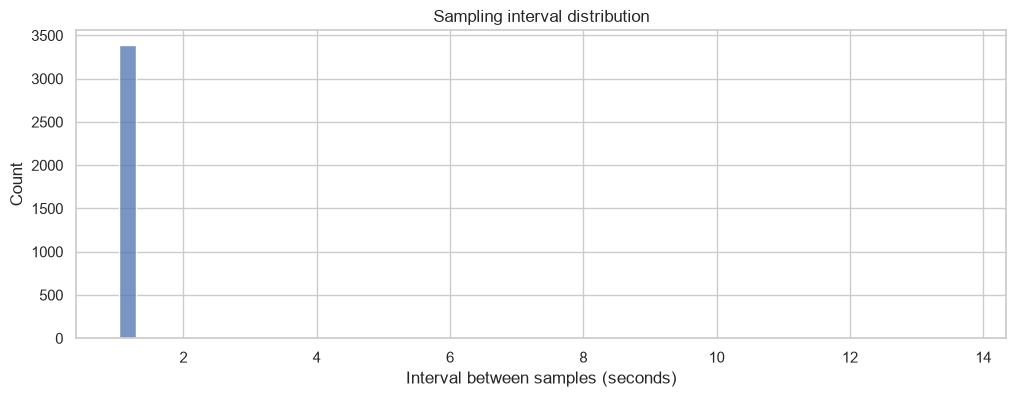

In [35]:
ordered = df.sort_values(['channel', 'time'])
intervals = ordered.groupby('channel')['time'].diff().dt.total_seconds()
sampling_summary = intervals.groupby(ordered['channel']).agg(
    median_interval_s='median', min_interval_s='min', max_interval_s='max',
    irregular_intervals='count'
)
display(sampling_summary)

plt.figure(figsize=(12, 4))
sns.histplot(intervals.dropna(), bins=50)
plt.xlabel('Interval between samples (seconds)')
plt.title('Sampling interval distribution')
plt.show()

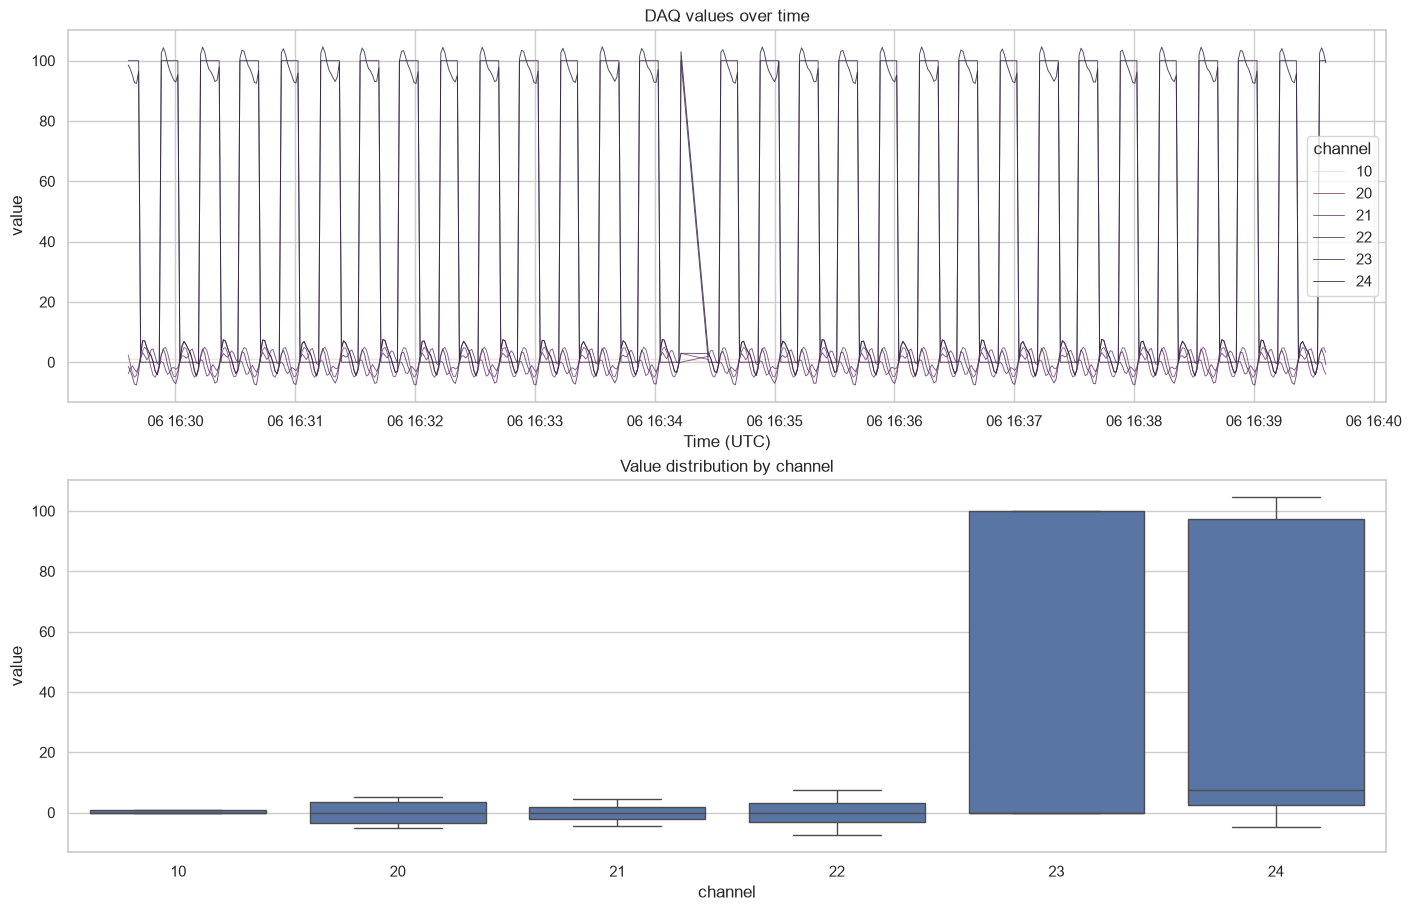

In [36]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), constrained_layout=True)
sns.lineplot(data=df.sort_values('time'), x='time', y='value', hue='channel',
             estimator=None, linewidth=0.7, alpha=0.8, ax=axes[0], legend='full')
axes[0].set_title('DAQ values over time')
axes[0].set_xlabel('Time (UTC)')
sns.boxplot(data=df, x='channel', y='value', ax=axes[1], showfliers=False)
axes[1].set_title('Value distribution by channel')
plt.show()

In [37]:
stats = df.groupby('channel')['value'].agg(['mean', 'std'])
df['z_score'] = (df['value'] - df['channel'].map(stats['mean'])) / df['channel'].map(stats['std'])
outliers = df[df['z_score'].abs() > 3].sort_values('z_score', key=lambda s: s.abs(), ascending=False)
print(f'Potential outliers (absolute within-channel z-score > 3): {len(outliers):,}')
display(outliers.head(20))

# Optional: hourly sample counts and average values
hourly = (df.set_index('time').groupby('channel')['value']
          .resample('1h').agg(['count', 'mean']).reset_index())
display(hourly.head())

Potential outliers (absolute within-channel z-score > 3): 0


,time,channel,value,z_score


,channel,time,count,mean
0,10,2026-08-06 16:00:00+00:00,567,0.495591
1,20,2026-08-06 16:00:00+00:00,567,-0.015041
2,21,2026-08-06 16:00:00+00:00,567,0.015700
3,22,2026-08-06 16:00:00+00:00,567,0.000659
4,23,2026-08-06 16:00:00+00:00,567,49.559083


## Cross-channel relationships

Samples are converted from long form (`time`, `channel`, `value`) to one row per timestamp. Pearson measures linear relationships and Spearman measures monotonic relationships. Neither establishes causation.

Aligned timestamps: 567 / 567


channel,10,20,21,22,23,24
time,,,,,,
2026-08-06 16:29:36.384332+00:00,1.0,2.378584,-3.796466,-1.417882,100.0,98.582118
2026-08-06 16:29:37.417895+00:00,1.0,-0.765132,-2.066397,-2.831530,100.0,97.168470
2026-08-06 16:29:38.452570+00:00,1.0,-3.599243,-1.189590,-4.788832,100.0,95.211168
2026-08-06 16:29:39.481900+00:00,1.0,-4.963871,-2.297854,-7.261726,100.0,92.738274
2026-08-06 16:29:40.515194+00:00,1.0,-4.316668,-3.243364,-7.560032,100.0,92.439968


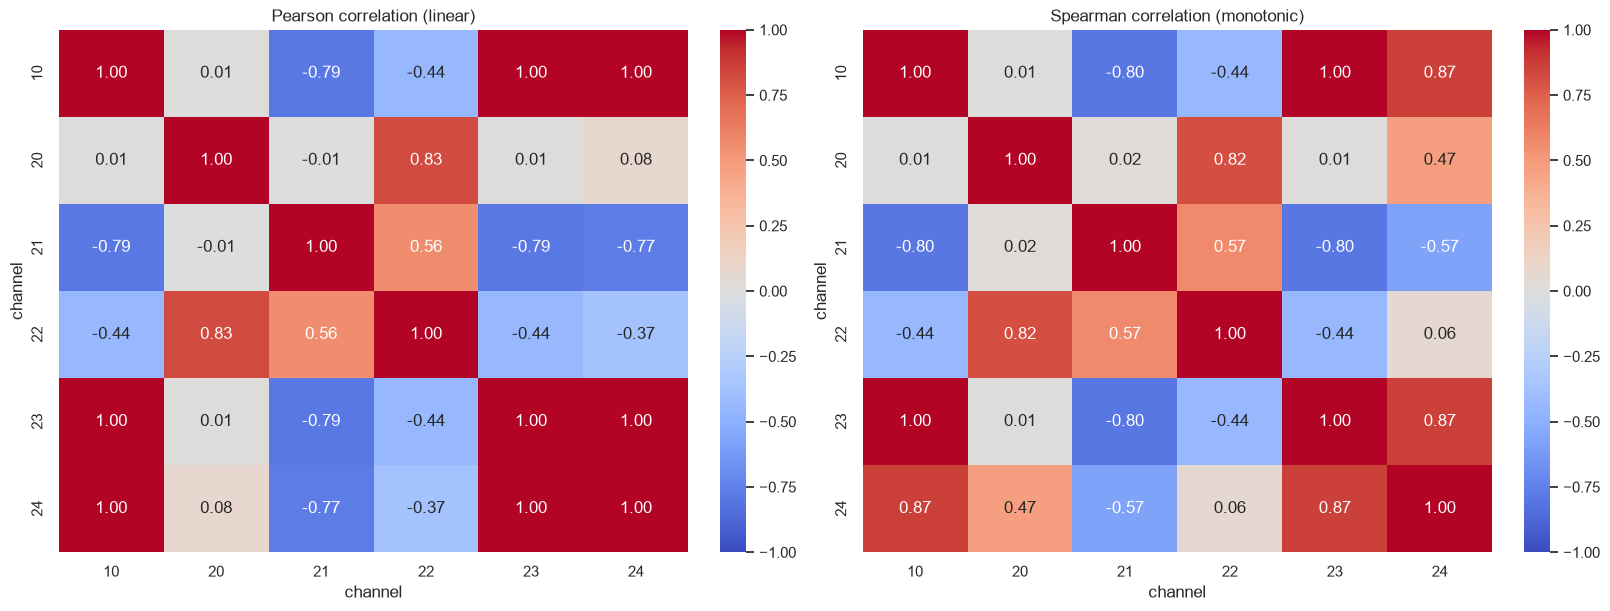

In [38]:
wide = (df.pivot_table(index='time', columns='channel', values='value', aggfunc='mean')
          .sort_index())
machine_feature_channels = [channel['channel'] for channel in sim_config.get('channels', [])
                            if channel.get('type') == 'machine' and not channel.get('training_label')]
available_features = [channel for channel in machine_feature_channels if channel in wide.columns]
if len(available_features) >= 2:
    wide = wide[available_features]

if wide.shape[1] < 2:
    raise ValueError('At least two channels are required for relationship analysis')

complete_samples = wide.dropna()
print(f'Aligned timestamps: {len(complete_samples):,} / {len(wide):,}')
display(complete_samples.head())

pearson = complete_samples.corr(method='pearson')
spearman = complete_samples.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
sns.heatmap(pearson, vmin=-1, vmax=1, center=0, cmap='coolwarm', annot=True, fmt='.2f', ax=axes[0])
axes[0].set_title('Pearson correlation (linear)')
sns.heatmap(spearman, vmin=-1, vmax=1, center=0, cmap='coolwarm', annot=True, fmt='.2f', ax=axes[1])
axes[1].set_title('Spearman correlation (monotonic)')
plt.show()

In [ ]:
# Rank pairs by same-timestamp linear relationship. Keep one half of the symmetric matrix.
pairs = (pearson.where(np.triu(np.ones(pearson.shape), k=1).astype(bool))
        .stack()
        .rename_axis(['channel_a', 'channel_b'])
        .rename('pearson_r')
        .reset_index()
        .rename(columns={'level_0': 'channel_a', 'level_1': 'channel_b'}))
pairs['abs_pearson_r'] = pairs['pearson_r'].abs()
pairs['spearman_r'] = [spearman.loc[a, b] for a, b in zip(pairs['channel_a'], pairs['channel_b'])]
pairs = pairs.sort_values('abs_pearson_r', ascending=False)
display(pairs.head(10).style.format({'pearson_r': '{:.3f}', 'spearman_r': '{:.3f}', 'abs_pearson_r': '{:.3f}'}))

# Scatter plots make the strongest relationships easier to validate visually.
top_pairs = pairs.head(min(4, len(pairs)))
fig, axes = plt.subplots(len(top_pairs), 1, figsize=(8, 4 * len(top_pairs)), squeeze=False)
for ax, (_, pair) in zip(axes.ravel(), top_pairs.iterrows()):
    a, b = pair['channel_a'], pair['channel_b']
    sns.regplot(x=complete_samples[a], y=complete_samples[b], ax=ax, scatter_kws={'alpha': 0.7})
    ax.set_title(f'Channels {a} and {b}: Pearson r = {pair["pearson_r"]:.3f}')
plt.tight_layout()
plt.show()

,channel_a,channel_b,pearson_r,abs_pearson_r,spearman_r
4,10,23,1.000,1.000,1.000
5,10,24,0.997,0.997,0.866
29,23,24,0.997,0.997,0.866
9,20,22,0.826,0.826,0.816
2,10,21,-0.794,0.794,-0.800
16,21,23,-0.794,0.794,-0.800
17,21,24,-0.774,0.774,-0.573
15,21,22,0.558,0.558,0.573
22,22,23,-0.440,0.440,-0.442
3,10,22,-0.440,0.440,-0.442


## Unsupervised ML: PCA

PCA finds shared patterns across all channels after putting them on the same scale. A small number of components explaining most variance suggests the channels move together. The production review below fits PCA only on known-good rows.

,component,explained_variance_ratio,cumulative_variance_ratio
0,PC1,66.1%,66.1%
1,PC2,28.2%,94.3%
2,PC3,5.7%,100.0%
3,PC4,0.0%,100.0%
4,PC5,0.0%,100.0%
5,PC6,0.0%,100.0%


component,PC1,PC2,PC3
channel,,,
10,-0.489,0.129,-0.265
20,0.062,0.751,0.296
21,0.443,-0.033,-0.802
22,0.302,0.606,-0.208
23,-0.489,0.129,-0.265
24,-0.480,0.186,-0.293


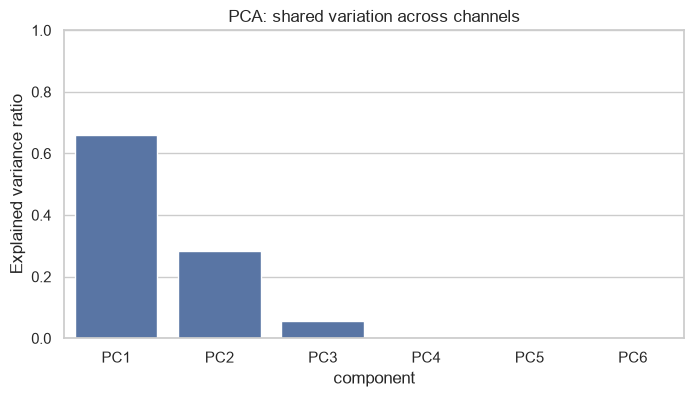

In [ ]:
# Standardize first so channels with larger units do not dominate the model.
scaled_values = (complete_samples - complete_samples.mean()) / complete_samples.std(ddof=0)
# SVD is a numerically stable implementation of PCA.
_, singular_values, components = np.linalg.svd(scaled_values, full_matrices=False)
explained_variance = singular_values ** 2 / (len(scaled_values) - 1)
explained_variance_ratio = explained_variance / explained_variance.sum()

pca_summary = pd.DataFrame({
    'component': [f'PC{i}' for i in range(1, len(components) + 1)],
    'explained_variance_ratio': explained_variance_ratio,
    'cumulative_variance_ratio': explained_variance_ratio.cumsum(),
})
display(pca_summary.style.format({'explained_variance_ratio': '{:.1%}', 'cumulative_variance_ratio': '{:.1%}'}))

loadings = pd.DataFrame(components.T, index=complete_samples.columns, columns=pca_summary['component'])
display(loadings.iloc[:, :min(3, len(loadings.columns))].style.format('{:.3f}'))

plt.figure(figsize=(8, 4))
sns.barplot(data=pca_summary, x='component', y='explained_variance_ratio', color='#4c72b0')
plt.ylim(0, 1)
plt.ylabel('Explained variance ratio')
plt.title('PCA: shared variation across channels')
plt.show()

# Production ML process review

This section mirrors machine_ml.py without replacing it. The notebook exposes each calculation for review; machine_ml.py remains the authoritative automated training and inference pipeline.

Process: aligned sensor rows → select verified healthy baseline → standardize → learn covariance and PCA → calculate anomaly distance → calibrate healthy/warning/critical thresholds → validate → create an LLM-readable inference.

## 1. Select model features and ground truth

Channels 0–6 are physical sensor inputs. Simulator channel 90 supplies labels only for baseline selection, threshold calibration, and validation; it is never included in the feature matrix. A real machine should replace channel 90 with verified healthy periods and maintenance outcomes.

In [ ]:
feature_details = [
    {
        'channel': int(channel['channel']),
        'name': channel.get('name', channel.get('signal')),
        'signal': channel.get('signal'),
        'unit': channel.get('unit', ''),
    }
    for channel in sim_config.get('channels', [])
    if channel.get('type') == 'machine' and not channel.get('training_label')
]
feature_channels = [feature['channel'] for feature in feature_details]
label_channels = [int(channel['channel']) for channel in sim_config.get('channels', [])
                  if channel.get('training_label') or channel.get('signal') == 'health_state']
label_channel = label_channels[0] if label_channels else None

all_wide = df.pivot_table(index='time', columns='channel', values='value', aggfunc='mean').sort_index()
missing_features = sorted(set(feature_channels) - set(all_wide.columns))
if missing_features:
    raise ValueError(f'Missing configured feature channels: {missing_features}')
if label_channel is None or label_channel not in all_wide.columns:
    raise ValueError('This review requires simulator ground-truth channel 90')

ml_samples = all_wide[feature_channels].dropna()
labels = all_wide[label_channel].reindex(ml_samples.index)
feature_table = pd.DataFrame(feature_details).set_index('channel')
display(feature_table)
print(f'Feature matrix: {ml_samples.shape[0]:,} timestamps × {ml_samples.shape[1]} sensors')
display(labels.value_counts().sort_index().rename(index={0.0: 'healthy', 1.0: 'warning', 2.0: 'critical'}).to_frame('samples'))

## 2. Learn the known-good multivariate baseline

Only rows labeled healthy are used to learn the baseline. Each sensor is standardized so rpm, degrees Celsius, amperes, and millimeters contribute on comparable scales. The regularized inverse covariance captures both normal ranges and normal relationships between sensors.

The anomaly score is the Mahalanobis distance: sqrt(z · inverse_covariance · zᵀ). A value can therefore be anomalous either because one sensor is far from normal or because the combination of otherwise plausible sensor values violates their learned relationship.

In [ ]:
healthy_samples = ml_samples.loc[labels == 0]
minimum_healthy_rows = max(10, len(feature_channels) + 2)
if len(healthy_samples) < minimum_healthy_rows:
    raise ValueError(f'Need at least {minimum_healthy_rows} healthy rows')

baseline_mean = healthy_samples.mean()
baseline_std = healthy_samples.std(ddof=0).replace(0, 1.0)
healthy_standardized = (healthy_samples - baseline_mean) / baseline_std

regularization = 0.05
covariance = np.cov(healthy_standardized.to_numpy(), rowvar=False)
regularized_covariance = covariance + np.eye(len(feature_channels)) * regularization
inverse_covariance = np.linalg.pinv(regularized_covariance)
healthy_scores = np.sqrt(np.maximum(
    np.einsum('ij,jk,ik->i', healthy_standardized, inverse_covariance, healthy_standardized), 0
))

baseline_review = pd.DataFrame({
    'sensor': [feature_table.loc[channel, 'name'] for channel in feature_channels],
    'mean': baseline_mean.to_numpy(),
    'standard_deviation': baseline_std.to_numpy(),
}, index=feature_channels)
baseline_review.index.name = 'channel'
display(baseline_review.style.format({'mean': '{:.4f}', 'standard_deviation': '{:.4f}'}))
print(f'Healthy anomaly score range: {healthy_scores.min():.3f} to {healthy_scores.max():.3f}')

## 3. Fit PCA on healthy behavior

PCA is used for explanation rather than the final status decision. It shows how many shared operating patterns describe the healthy machine and which sensors participate in those patterns.

In [ ]:
_, healthy_singular_values, healthy_components = np.linalg.svd(healthy_standardized, full_matrices=False)
healthy_explained_variance = healthy_singular_values ** 2 / (len(healthy_standardized) - 1)
healthy_explained_ratio = healthy_explained_variance / healthy_explained_variance.sum()
healthy_cumulative_ratio = healthy_explained_ratio.cumsum()
retained_components = min(int(np.searchsorted(healthy_cumulative_ratio, 0.95) + 1), len(feature_channels))

healthy_pca_summary = pd.DataFrame({
    'component': [f'PC{index}' for index in range(1, len(healthy_components) + 1)],
    'explained_variance_ratio': healthy_explained_ratio,
    'cumulative_variance_ratio': healthy_cumulative_ratio,
})
healthy_loadings = pd.DataFrame(
    healthy_components.T,
    index=[feature_table.loc[channel, 'name'] for channel in feature_channels],
    columns=healthy_pca_summary['component'],
)
display(healthy_pca_summary.style.format({'explained_variance_ratio': '{:.1%}', 'cumulative_variance_ratio': '{:.1%}'}))
display(healthy_loadings.iloc[:, :retained_components].style.format('{:.3f}'))
print(f'Retain {retained_components} component(s), explaining {healthy_cumulative_ratio[retained_components - 1]:.1%} of healthy variation.')

## 4. Calibrate warning and critical thresholds

The healthy baseline produces a continuous anomaly score. Simulator labels calibrate two boundaries: the warning boundary lies between the high end of healthy scores and low end of warning scores; the critical boundary lies between late-warning and early-critical score distributions. This calibration channel is not needed during inference.

In [ ]:
all_standardized = (ml_samples - baseline_mean) / baseline_std
all_scores = np.sqrt(np.maximum(
    np.einsum('ij,jk,ik->i', all_standardized, inverse_covariance, all_standardized), 0
))
warning_scores = all_scores[labels.to_numpy() == 1]
critical_scores = all_scores[labels.to_numpy() == 2]

healthy_edge = float(np.quantile(healthy_scores, 0.99))
warning_edge = float(np.quantile(warning_scores, 0.01))
warning_threshold = (healthy_edge + warning_edge) / 2
late_warning = float(np.quantile(warning_scores, 0.90))
early_critical = float(np.quantile(critical_scores, 0.10))
critical_threshold = max((late_warning + early_critical) / 2, warning_threshold * 1.45)

predicted_numeric = np.where(all_scores >= critical_threshold, 2,
                             np.where(all_scores >= warning_threshold, 1, 0))
class_names = {0: 'healthy', 1: 'warning', 2: 'critical'}
truth_names = labels.astype(int).map(class_names)
predicted_names = pd.Series(predicted_numeric, index=ml_samples.index).map(class_names)
accuracy = float((truth_names == predicted_names).mean())
confusion = pd.crosstab(truth_names, predicted_names, rownames=['actual'], colnames=['predicted'])

print(f'Warning threshold: {warning_threshold:.3f}')
print(f'Critical threshold: {critical_threshold:.3f}')
print(f'In-sample simulator accuracy: {accuracy:.2%}')
display(confusion)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ml_samples.index, all_scores, linewidth=1, label='Anomaly score')
ax.axhline(warning_threshold, color='#d99b00', linestyle='--', label='Warning threshold')
ax.axhline(critical_threshold, color='#c9342c', linestyle='--', label='Critical threshold')
ax.set_ylabel('Mahalanobis anomaly score')
ax.set_title('Machine anomaly score over time')
ax.legend()
plt.show()

## 5. Review representative real-time decisions

For each state below, the notebook selects a representative timestamp, reports the model decision and health percentage, and lists the three sensors furthest from their healthy baseline. In production the same calculation is applied to the newest complete timestamp from TimescaleDB.

In [ ]:
def health_percent_for_score(score):
    if score <= warning_threshold:
        return 100 - 20 * score / warning_threshold
    if score <= critical_threshold:
        return 80 - 40 * (score - warning_threshold) / (critical_threshold - warning_threshold)
    return max(0.0, 40 - 40 * (score - critical_threshold) / critical_threshold)

decision_rows = []
contributor_rows = []
for actual_numeric, actual_name in class_names.items():
    positions = np.flatnonzero(labels.to_numpy() == actual_numeric)
    position = int(positions[len(positions) // 2])
    timestamp = ml_samples.index[position]
    score = float(all_scores[position])
    predicted_name = class_names[int(predicted_numeric[position])]
    decision_rows.append({
        'sample_time': timestamp,
        'simulator_truth': actual_name,
        'ml_status': predicted_name,
        'health_percent': health_percent_for_score(score),
        'anomaly_score': score,
    })
    deviations = all_standardized.iloc[position].abs().sort_values(ascending=False).head(3)
    for channel, deviation in deviations.items():
        contributor_rows.append({
            'state': actual_name,
            'sensor': feature_table.loc[channel, 'name'],
            'value': ml_samples.iloc[position][channel],
            'unit': feature_table.loc[channel, 'unit'],
            'absolute_deviation_sigma': deviation,
        })

display(pd.DataFrame(decision_rows).style.format({'health_percent': '{:.1f}%', 'anomaly_score': '{:.3f}'}))
display(pd.DataFrame(contributor_rows).style.format({'value': '{:.3f}', 'absolute_deviation_sigma': '{:.2f}'}))

## 6. Verify parity with the production Python pipeline

This final check calls machine_ml.py using the same DataFrame and configuration. It confirms that the review calculations match the deployable pipeline. The notebook does not overwrite artifacts; use the Python CLI to generate production files.

In [ ]:
from machine_ml import infer_latest, train_model

production_frame = df[['time', 'channel', 'value']].copy()
production_model, production_report = train_model(production_frame, sim_config)
production_latest = infer_latest(production_frame, production_model)

parity = pd.DataFrame({
    'notebook': [warning_threshold, critical_threshold, accuracy],
    'machine_ml.py': [
        production_model['thresholds']['warning'],
        production_model['thresholds']['critical'],
        production_report['simulator_validation']['accuracy'],
    ],
}, index=['warning_threshold', 'critical_threshold', 'simulator_accuracy'])
parity['matches'] = np.isclose(parity['notebook'], parity['machine_ml.py'])
display(parity.style.format({'notebook': '{:.6f}', 'machine_ml.py': '{:.6f}'}))
display(pd.DataFrame(production_report['strongest_relationships']).head(8))
display(production_latest['machine_quality'])

assert parity['matches'].all(), 'Notebook calculations have drifted from machine_ml.py'
print('Review complete: notebook and production pipeline match.')

## Review conclusions and production boundary

- The model learns normal multivariate sensor behavior rather than isolated fixed limits.
- PCA explains shared healthy variation; Mahalanobis distance produces the operational anomaly score.
- Simulator channel 90 is excluded from features and is used only for training review and threshold calibration.
- The simulator validation is in-sample and must not be interpreted as expected real-machine accuracy.
- Before unattended production use, retrain on verified healthy real-machine data, validate against maintenance events, detect stale or missing sensors, and retain a deterministic safety interlock. The LLM should explain and route ML results, not control the machine by itself.